<a href="https://colab.research.google.com/github/Shamima21/TumorPhylogenyLearning/blob/main/Learning_Conserved_Evolutionary_Patterns_of_Cancer_Metastasis_from_Tumour_Phylogenies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 1. SETUP
# ============================================================

required_packages <- c(
  "igraph",
  "dplyr",
  "tidyr",
  "ggplot2",
  "purrr",
  "tibble",
  "cluster"
)

new_packages <- required_packages[
  !(required_packages %in% installed.packages()[, "Package"])
]

if (length(new_packages) > 0) {
  install.packages(new_packages)
}

library(igraph)
library(dplyr)
library(tidyr)
library(ggplot2)
library(purrr)
library(tibble)
library(cluster)

set.seed(42)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union



Attaching package: ‘dplyr’


The following objects are masked from ‘package:igraph’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following object is masked from ‘package:igraph’:

    crossing



Attaching package: ‘purrr’


The following objects are masked from ‘package:igraph’:

    compose, simplify



Attaching package: ‘tibble’


The following object is masked from ‘package:igraph’:

    as_data_frame




In [4]:
# ============================================================
# 2. LOAD DATA
# ============================================================

tree_file <- "/content/sample_data/20221109_TRACERx421_phylogenetic_trees.rds"

stopifnot(file.exists(tree_file))

trees <- readRDS(tree_file)

cat("Object class:", class(trees), "\n")
cat("Number of entries:", length(trees), "\n")
cat("First patient IDs:\n")

head(names(trees))

Object class: list 
Number of entries: 403 
First patient IDs:


[1] "CRUK0005" "CRUK0057" "CRUK0039" "CRUK0196" "CRUK0023" "CRUK0050"

In [5]:
# ============================================================
#the actual number of analysable phylogenies, not automatically assume all 421 patients have valid corrected trees.
# ============================================================
summary_table <- tibble(
  patient_id = names(trees),
  has_corrected_tree = sapply(
    trees,
    function(x) !is.null(x$graph_pyclone$Corrected_tree)
  )
)

table(summary_table$has_corrected_tree)


TRUE 
 403 

In [6]:
#Use one patient only for debugging
patient_id <- "CRUK0005"

patient <- trees[[patient_id]]

names(patient)
names(patient$graph_pyclone)

patient$graph_pyclone$Corrected_tree
patient$graph_pyclone$trunk
patient$graph_pyclone$edgelength

[1] "ccf_table_pyclone_clean" "merged_clusters"        
[3] "cpn_removed_clusters"    "tree_removed_clusters"  
[5] "graph_pyclone"           "nested_pyclone"         
[7] "clonality_out"           "tumour_id"

[1] "Corrected_tree"          "Original_tree"          
[3] "ccf_per_level"           "edgelength"             
[5] "trunk"                   "alt_trees"              
[7] "consensus_branches"      "nested_clust"           
[9] "consensus_relationships"

last_ancestor,terminal_node
4,3
2,4
19,5
3,9
13,12
9,13
12,18
20,19
3,20
5,21


[1] "2"


  1   2   3   4   5   6   7   8   9  10  11  12  13  14  16  17  18  19  20  21 
462 259 184 177  95  67  33  32  25  22  19  15  12  11  11  10   8   8   6   6 
 22  23  25 
  5   5   5 

In [7]:
# ============================================================
# 3. TREE STANDARDIZATION
# ============================================================

standardize_tree <- function(patient_object, patient_id = NA_character_) {

  corrected_tree <- patient_object$graph_pyclone$Corrected_tree
  trunk <- patient_object$graph_pyclone$trunk
  edge_lengths <- patient_object$graph_pyclone$edgelength

  # No valid tree
  if (is.null(corrected_tree) || length(corrected_tree) == 0) {
    return(NULL)
  }

  # Convert edge matrix into data frame
  edges <- as.data.frame(
    corrected_tree,
    stringsAsFactors = FALSE
  )

  if (ncol(edges) < 2) {
    return(NULL)
  }

  edges <- edges[, 1:2]

  colnames(edges) <- c("parent", "child")

  edges$parent <- as.character(edges$parent)
  edges$child  <- as.character(edges$child)

  trunk <- as.character(trunk)

  # Construct directed graph
  g <- graph_from_data_frame(
    edges,
    directed = TRUE
  )

  # Identify node types
  nodes <- tibble(
    cluster = V(g)$name,
    indegree = degree(g, mode = "in"),
    outdegree = degree(g, mode = "out")
  ) %>%
    mutate(
      node_type = case_when(
        cluster == trunk ~ "Trunk",
        outdegree == 0 ~ "Terminal",
        TRUE ~ "Internal"
      )
    )

  # Add mutation counts if available
  if (!is.null(edge_lengths)) {

    mutation_table <- tibble(
      cluster = as.character(names(edge_lengths)),
      mutation_count = as.numeric(edge_lengths)
    )

    nodes <- nodes %>%
      left_join(
        mutation_table,
        by = "cluster"
      )
  } else {

    nodes$mutation_count <- NA_real_

  }

  return(
    list(
      patient_id = patient_id,
      graph = g,
      edges = edges,
      nodes = nodes,
      trunk = trunk
    )
  )
}

In [8]:
#TEST
test_tree <- standardize_tree(
  trees[["CRUK0005"]],
  "CRUK0005"
)

test_tree$edges
test_tree$nodes
test_tree$trunk

parent,child
<chr>,<chr>
4,3
2,4
19,5
3,9
13,12
9,13
12,18
20,19
3,20


cluster,indegree,outdegree,node_type,mutation_count
<chr>,<dbl>,<dbl>,<chr>,<dbl>
4,1,1,Internal,177
2,0,2,Trunk,259
19,1,1,Internal,8
3,1,2,Internal,184
13,1,2,Internal,12
9,1,1,Internal,25
12,1,1,Internal,15
20,1,1,Internal,6
5,1,1,Internal,95


[1] "2"

In [9]:
#CHECK TREE QUALITY
#====================================================
#verify:

#The tree exists.
#The root exists.
#The root has no parent.
#The graph is connected.
#The graph is acyclic (a DAG).
#Every non-root node has exactly one parent.
#A tree with V nodes must have exactly V−1 edges.
#===================================================


validate_tree <- function(std_tree) {

  # Check if the tree exists
  if (is.null(std_tree)) {
    return(FALSE)
  }

  g <- std_tree$graph
  root <- std_tree$trunk

  # Check if the root node exists
  if (!(root %in% V(g)$name)) {
    return(FALSE)
  }

  # Root should have no parent
  root_indegree <- degree(g, v = root, mode = "in")

  # Every non-root node should have exactly one parent
  indegrees <- degree(g, mode = "in")
  non_root <- V(g)$name != root
  valid_parents <- all(indegrees[non_root] == 1)

  # Tree should be connected
  connected <- is_connected(as_undirected(g))

  # Tree should contain no cycles
  acyclic <- is_dag(g)

  # A tree must satisfy |E| = |V| - 1
  valid_edges <- (ecount(g) == vcount(g) - 1)

  return(
    root_indegree == 0 &&
    valid_parents &&
    connected &&
    acyclic &&
    valid_edges
  )
}

In [10]:
validate_tree(test_tree)

[1] TRUE

In [11]:
#Standardize all patient trees  And keep the valid ones:
standardized_trees <- map2(
  trees,
  names(trees),
  ~ standardize_tree(.x, .y)
)

names(standardized_trees) <- names(trees)
valid_tree <- map_lgl(
  standardized_trees,
  validate_tree
)

table(valid_tree)
standardized_trees_valid <-
  standardized_trees[valid_tree]

length(standardized_trees_valid)

valid_tree
FALSE  TRUE 
    5   398 

[1] 398

In [12]:
# ============================================================
# 4. QUANTITATIVE FEATURE EXTRACTION
# ============================================================

extract_tree_features <- function(std_tree) {

  g <- std_tree$graph
  nodes <- std_tree$nodes
  root <- std_tree$trunk

  # Basic counts
  n_nodes <- vcount(g)
  n_edges <- ecount(g)

  n_terminal <- sum(
    nodes$node_type == "Terminal"
  )

  n_internal <- sum(
    nodes$node_type == "Internal"
  )

  n_branching <- sum(
    nodes$outdegree > 1
  )

  # Degree-based features
  max_outdegree <- max(
    nodes$outdegree,
    na.rm = TRUE
  )

  mean_outdegree <- mean(
    nodes$outdegree,
    na.rm = TRUE
  )

  # Distance from root
  d <- distances(
    g,
    v = root,
    to = V(g),
    mode = "out"
  )

  depths <- as.numeric(d[1, ])

  depths <- depths[
    is.finite(depths)
  ]

  max_depth <- max(depths)
  mean_depth <- mean(depths)

  # Terminal-node depths
  terminal_nodes <- nodes$cluster[
    nodes$node_type == "Terminal"
  ]

  terminal_depths <- distances(
    g,
    v = root,
    to = terminal_nodes,
    mode = "out"
  )

  terminal_depths <-
    as.numeric(terminal_depths[1, ])

  mean_terminal_depth <-
    mean(terminal_depths)

  max_terminal_depth <-
    max(terminal_depths)

  # Mutation-related features
  mut <- nodes$mutation_count

  total_mutations <- sum(
    mut,
    na.rm = TRUE
  )

  mean_mutations <- mean(
    mut,
    na.rm = TRUE
  )

  max_mutations <- max(
    mut,
    na.rm = TRUE
  )

  # Trunk mutation count
  trunk_mutations <- nodes %>%
    filter(cluster == root) %>%
    pull(mutation_count)

  if (length(trunk_mutations) == 0) {
    trunk_mutations <- NA_real_
  }

  tibble(
    patient_id = std_tree$patient_id,

    n_nodes = n_nodes,
    n_edges = n_edges,

    n_internal = n_internal,
    n_terminal = n_terminal,
    n_branching_nodes = n_branching,

    max_outdegree = max_outdegree,
    mean_outdegree = mean_outdegree,

    max_depth = max_depth,
    mean_depth = mean_depth,

    mean_terminal_depth = mean_terminal_depth,
    max_terminal_depth = max_terminal_depth,

    trunk_mutations = trunk_mutations,
    total_mutations = total_mutations,
    mean_mutations_per_clone = mean_mutations,
    max_mutations_per_clone = max_mutations
  )
}

In [13]:
#Test on one patient:

extract_tree_features(test_tree)

patient_id,n_nodes,n_edges,n_internal,n_terminal,n_branching_nodes,max_outdegree,mean_outdegree,max_depth,mean_depth,mean_terminal_depth,max_terminal_depth,trunk_mutations,total_mutations,mean_mutations_per_clone,max_mutations_per_clone
<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CRUK0005,15,14,10,4,3,2,0.9333333,7,3.933333,5,7,259,1321,88.06667,462


In [14]:
# ============================================================
# 5. CREATE FEATURE MATRIX
# ============================================================

feature_matrix <- purrr::map_dfr(
  standardized_trees,
  extract_tree_features
)

# Check result
dim(feature_matrix)
head(feature_matrix)
summary(feature_matrix)

Warning message in max(terminal_depths):
“no non-missing arguments to max; returning -Inf”
Warning message in max(terminal_depths):
“no non-missing arguments to max; returning -Inf”
Warning message in max(terminal_depths):
“no non-missing arguments to max; returning -Inf”
Warning message in max(terminal_depths):
“no non-missing arguments to max; returning -Inf”
Warning message in max(terminal_depths):
“no non-missing arguments to max; returning -Inf”


[1] 403  16

patient_id,n_nodes,n_edges,n_internal,n_terminal,n_branching_nodes,max_outdegree,mean_outdegree,max_depth,mean_depth,mean_terminal_depth,max_terminal_depth,trunk_mutations,total_mutations,mean_mutations_per_clone,max_mutations_per_clone
<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CRUK0005,15,14,10,4,3,2,0.9333333,7,3.933333,5.000000,7,259,1321,88.06667,462
CRUK0057,6,5,3,2,1,2,0.8333333,3,1.500000,2.500000,3,1040,1149,191.50000,1040
CRUK0039,5,4,2,2,1,2,0.8000000,2,1.200000,2.000000,2,1003,1099,219.80000,1003
CRUK0196,7,6,3,3,2,2,0.8571429,3,1.714286,2.666667,3,652,724,103.42857,652
CRUK0023,11,10,6,4,2,3,0.9090909,4,2.000000,2.750000,4,220,351,31.90909,220
CRUK0050,4,3,1,2,1,2,0.7500000,2,1.250000,2.000000,2,176,197,49.25000,176


     patient_id     n_nodes         n_edges         n_internal    
 Length   :403   Min.   : 1.00   Min.   : 1.000   Min.   : 0.000  
 N.unique :403   1st Qu.: 6.00   1st Qu.: 5.000   1st Qu.: 2.000  
 N.blank  :  0   Median : 9.00   Median : 8.000   Median : 5.000  
 Min.nchar:  8   Mean   :10.15   Mean   : 9.164   Mean   : 5.643  
 Max.nchar: 16   3rd Qu.:13.00   3rd Qu.:12.000   3rd Qu.: 8.000  
                 Max.   :40.00   Max.   :39.000   Max.   :31.000  
                                                                  
   n_terminal     n_branching_nodes max_outdegree   mean_outdegree  
 Min.   : 0.000   Min.   :0.000     Min.   :1.000   Min.   :0.5000  
 1st Qu.: 2.000   1st Qu.:1.000     1st Qu.:2.000   1st Qu.:0.8333  
 Median : 3.000   Median :2.000     Median :2.000   Median :0.8889  
 Mean   : 3.509   Mean   :2.012     Mean   :2.382   Mean   :0.8632  
 3rd Qu.: 4.000   3rd Qu.:3.000     3rd Qu.:3.000   3rd Qu.:0.9286  
 Max.   :10.000   Max.   :7.000     Max.   :7.000 

In [15]:
summary(feature_matrix)

     patient_id     n_nodes         n_edges         n_internal    
 Length   :403   Min.   : 1.00   Min.   : 1.000   Min.   : 0.000  
 N.unique :403   1st Qu.: 6.00   1st Qu.: 5.000   1st Qu.: 2.000  
 N.blank  :  0   Median : 9.00   Median : 8.000   Median : 5.000  
 Min.nchar:  8   Mean   :10.15   Mean   : 9.164   Mean   : 5.643  
 Max.nchar: 16   3rd Qu.:13.00   3rd Qu.:12.000   3rd Qu.: 8.000  
                 Max.   :40.00   Max.   :39.000   Max.   :31.000  
                                                                  
   n_terminal     n_branching_nodes max_outdegree   mean_outdegree  
 Min.   : 0.000   Min.   :0.000     Min.   :1.000   Min.   :0.5000  
 1st Qu.: 2.000   1st Qu.:1.000     1st Qu.:2.000   1st Qu.:0.8333  
 Median : 3.000   Median :2.000     Median :2.000   Median :0.8889  
 Mean   : 3.509   Mean   :2.012     Mean   :2.382   Mean   :0.8632  
 3rd Qu.: 4.000   3rd Qu.:3.000     3rd Qu.:3.000   3rd Qu.:0.9286  
 Max.   :10.000   Max.   :7.000     Max.   :7.000 

In [16]:
#sAVE ALL FEATURES
write.csv(
  feature_matrix,
  "TRACERx421_tree_features.csv",
  row.names = FALSE
)

In [17]:
# ============================================================
# BIOLOGICAL / EVOLUTIONARY FEATURE EXTRACTION
# ============================================================

extract_biological_features <- function(std_tree) {

  if (is.null(std_tree)) {
    return(NULL)
  }

  g     <- std_tree$graph
  nodes <- std_tree$nodes
  root  <- std_tree$trunk

  # ----------------------------------------------------------
  # 1. Mutation information
  # ----------------------------------------------------------

  mut <- nodes$mutation_count

  # Total mutation burden
  total_mutations <- sum(mut, na.rm = TRUE)

  # Trunk mutation burden
  trunk_mutations <- nodes$mutation_count[
    nodes$cluster == root
  ]

  if (length(trunk_mutations) == 0 ||
      is.na(trunk_mutations)) {
    trunk_mutations <- 0
  }

  # Branch mutations = all non-trunk mutations
  branch_mutations <- sum(
    nodes$mutation_count[
      nodes$cluster != root
    ],
    na.rm = TRUE
  )

  # ----------------------------------------------------------
  # 2. Trunk vs branch mutation contribution
  # ----------------------------------------------------------

  if (total_mutations > 0) {

    trunk_mutation_fraction <-
      trunk_mutations / total_mutations

    branch_mutation_fraction <-
      branch_mutations / total_mutations

  } else {

    trunk_mutation_fraction <- NA_real_
    branch_mutation_fraction <- NA_real_
  }

  # Ratio between early and later mutation burden
  if (branch_mutations > 0) {

    trunk_branch_ratio <-
      trunk_mutations / branch_mutations

  } else {

    trunk_branch_ratio <- NA_real_
  }

  # ----------------------------------------------------------
  # 3. Branch mutation heterogeneity
  # ----------------------------------------------------------

  non_trunk_mutations <- nodes$mutation_count[
    nodes$cluster != root
  ]

  mean_branch_mutations <- mean(
    non_trunk_mutations,
    na.rm = TRUE
  )

  sd_branch_mutations <- sd(
    non_trunk_mutations,
    na.rm = TRUE
  )

  branch_mutation_variance <- var(
    non_trunk_mutations,
    na.rm = TRUE
  )

  # ----------------------------------------------------------
  # 4. Diversification timing
  # ----------------------------------------------------------

  # Distance of every node from root
  depth_matrix <- distances(
    g,
    v = root,
    to = V(g),
    mode = "out"
  )

  node_depth <- as.numeric(depth_matrix[1, ])

  names(node_depth) <- V(g)$name

  # Nodes that create more than one descendant branch
  branching_nodes <- nodes$cluster[
    nodes$outdegree > 1
  ]

  if (length(branching_nodes) > 0) {

    branching_depths <-
      node_depth[branching_nodes]

    first_branching_depth <-
      min(branching_depths, na.rm = TRUE)

    mean_branching_depth <-
      mean(branching_depths, na.rm = TRUE)

  } else {

    first_branching_depth <- NA_real_
    mean_branching_depth <- NA_real_
  }

  max_depth <- max(
    node_depth[is.finite(node_depth)],
    na.rm = TRUE
  )

  # Normalize diversification timing
  if (!is.na(first_branching_depth) &&
      max_depth > 0) {

    diversification_timing <-
      first_branching_depth / max_depth

  } else {

    diversification_timing <- NA_real_
  }

  # ----------------------------------------------------------
  # Return patient-level biological/evolutionary features
  # ----------------------------------------------------------

  tibble(
    patient_id = std_tree$patient_id,

    trunk_mutations = trunk_mutations,
    branch_mutations = branch_mutations,

    trunk_mutation_fraction =
      trunk_mutation_fraction,

    branch_mutation_fraction =
      branch_mutation_fraction,

    trunk_branch_ratio =
      trunk_branch_ratio,

    mean_branch_mutations =
      mean_branch_mutations,

    sd_branch_mutations =
      sd_branch_mutations,

    branch_mutation_variance =
      branch_mutation_variance,

    first_branching_depth =
      first_branching_depth,

    mean_branching_depth =
      mean_branching_depth,

    diversification_timing =
      diversification_timing
  )
}

In [18]:
bio_test <- extract_biological_features(
  test_tree
)

bio_test

patient_id,trunk_mutations,branch_mutations,trunk_mutation_fraction,branch_mutation_fraction,trunk_branch_ratio,mean_branch_mutations,sd_branch_mutations,branch_mutation_variance,first_branching_depth,mean_branching_depth,diversification_timing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CRUK0005,259,1062,0.1960636,0.8039364,0.2438795,75.85714,127.0662,16145.82,0,2,0


In [19]:
#for all patients
biological_feature_matrix <- map_dfr(
  standardized_trees_valid,
  extract_biological_features
)

dim(biological_feature_matrix)

head(biological_feature_matrix)

#save:

write.csv(
  biological_feature_matrix,
  "TRACERx421_biological_features.csv",
  row.names = FALSE
)

[1] 398  12

patient_id,trunk_mutations,branch_mutations,trunk_mutation_fraction,branch_mutation_fraction,trunk_branch_ratio,mean_branch_mutations,sd_branch_mutations,branch_mutation_variance,first_branching_depth,mean_branching_depth,diversification_timing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CRUK0005,259,1062,0.1960636,0.80393641,0.2438795,75.85714,127.066220,16145.82418,0,2.0,0.0
CRUK0057,1040,109,0.9051349,0.09486510,9.5412844,21.80000,14.686729,215.70000,0,0.0,0.0
CRUK0039,1003,96,0.9126479,0.08735214,10.4479167,24.00000,17.606817,310.00000,0,0.0,0.0
CRUK0196,652,72,0.9005525,0.09944751,9.0555556,12.00000,5.585696,31.20000,0,1.0,0.0
CRUK0023,220,131,0.6267806,0.37321937,1.6793893,13.10000,8.685237,75.43333,0,0.5,0.0
CRUK0050,176,21,0.8934010,0.10659898,8.3809524,7.00000,1.732051,3.00000,1,1.0,0.5


In [20]:
# ============================================================
# 6. PATIENT-LEVEL EVOLUTIONARY FEATURE MATRIX
#    Combine Structural + Biological Features
# ============================================================

library(dplyr)

# ------------------------------------------------------------
# 1. Check dimensions of the two matrices
# ------------------------------------------------------------

cat("Structural feature matrix:",
    nrow(feature_matrix), "patients x",
    ncol(feature_matrix), "columns\n")

cat("Biological feature matrix:",
    nrow(biological_feature_matrix), "patients x",
    ncol(biological_feature_matrix), "columns\n")


# ------------------------------------------------------------
# 2. Check patient overlap
# ------------------------------------------------------------

common_patients <- intersect(
  feature_matrix$patient_id,
  biological_feature_matrix$patient_id
)

cat("Patients present in both matrices:",
    length(common_patients), "\n")


# Patients present only in structural matrix
structural_only <- setdiff(
  feature_matrix$patient_id,
  biological_feature_matrix$patient_id
)

# Patients present only in biological matrix
biological_only <- setdiff(
  biological_feature_matrix$patient_id,
  feature_matrix$patient_id
)

cat("Structural only:", length(structural_only), "\n")
cat("Biological only:", length(biological_only), "\n")


# ------------------------------------------------------------
# 3. Remove duplicated feature names before merging
# ------------------------------------------------------------

# trunk_mutations occurs in BOTH matrices.
# Keep it from the structural matrix and remove the duplicate
# from the biological matrix.

biological_features_clean <- biological_feature_matrix %>%
  select(
    -trunk_mutations
  )


# ------------------------------------------------------------
# 4. Merge by patient_id
# ------------------------------------------------------------

patient_level_feature_matrix <- feature_matrix %>%
  inner_join(
    biological_features_clean,
    by = "patient_id"
  )


# ------------------------------------------------------------
# 5. Inspect final patient-level matrix
# ------------------------------------------------------------

cat(
  "\nFinal Patient-Level Evolutionary Feature Matrix:\n"
)

cat(
  nrow(patient_level_feature_matrix),
  "patients x",
  ncol(patient_level_feature_matrix),
  "columns\n"
)

head(patient_level_feature_matrix)

summary(patient_level_feature_matrix)

Structural feature matrix: 403 patients x 16 columns
Biological feature matrix: 398 patients x 12 columns
Patients present in both matrices: 398 
Structural only: 5 
Biological only: 0 

Final Patient-Level Evolutionary Feature Matrix:
398 patients x 26 columns


patient_id,n_nodes,n_edges,n_internal,n_terminal,n_branching_nodes,max_outdegree,mean_outdegree,max_depth,mean_depth,⋯,branch_mutations,trunk_mutation_fraction,branch_mutation_fraction,trunk_branch_ratio,mean_branch_mutations,sd_branch_mutations,branch_mutation_variance,first_branching_depth,mean_branching_depth,diversification_timing
<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CRUK0005,15,14,10,4,3,2,0.9333333,7,3.933333,⋯,1062,0.1960636,0.80393641,0.2438795,75.85714,127.066220,16145.82418,0,2.0,0.0
CRUK0057,6,5,3,2,1,2,0.8333333,3,1.500000,⋯,109,0.9051349,0.09486510,9.5412844,21.80000,14.686729,215.70000,0,0.0,0.0
CRUK0039,5,4,2,2,1,2,0.8000000,2,1.200000,⋯,96,0.9126479,0.08735214,10.4479167,24.00000,17.606817,310.00000,0,0.0,0.0
CRUK0196,7,6,3,3,2,2,0.8571429,3,1.714286,⋯,72,0.9005525,0.09944751,9.0555556,12.00000,5.585696,31.20000,0,1.0,0.0
CRUK0023,11,10,6,4,2,3,0.9090909,4,2.000000,⋯,131,0.6267806,0.37321937,1.6793893,13.10000,8.685237,75.43333,0,0.5,0.0
CRUK0050,4,3,1,2,1,2,0.7500000,2,1.250000,⋯,21,0.8934010,0.10659898,8.3809524,7.00000,1.732051,3.00000,1,1.0,0.5


     patient_id     n_nodes         n_edges         n_internal    
 Length   :398   Min.   : 2.00   Min.   : 1.000   Min.   : 0.000  
 N.unique :398   1st Qu.: 6.00   1st Qu.: 5.000   1st Qu.: 2.000  
 N.blank  :  0   Median : 9.00   Median : 8.000   Median : 5.000  
 Min.nchar:  8   Mean   :10.27   Mean   : 9.266   Mean   : 5.714  
 Max.nchar: 16   3rd Qu.:13.00   3rd Qu.:12.000   3rd Qu.: 8.000  
                 Max.   :40.00   Max.   :39.000   Max.   :31.000  
                                                                  
   n_terminal     n_branching_nodes max_outdegree   mean_outdegree  
 Min.   : 1.000   Min.   :0.000     Min.   :1.000   Min.   :0.5000  
 1st Qu.: 2.000   1st Qu.:1.000     1st Qu.:2.000   1st Qu.:0.8333  
 Median : 3.000   Median :2.000     Median :2.000   Median :0.8889  
 Mean   : 3.553   Mean   :2.038     Mean   :2.399   Mean   :0.8615  
 3rd Qu.: 4.000   3rd Qu.:3.000     3rd Qu.:3.000   3rd Qu.:0.9231  
 Max.   :10.000   Max.   :7.000     Max.   :7.000 

In [21]:
# ============================================================
# SAVE FINAL PATIENT-LEVEL FEATURE MATRIX
# ============================================================

write.csv(
  patient_level_feature_matrix,
  "TRACERx421_patient_level_evolutionary_feature_matrix.csv",
  row.names = FALSE
)

cat(
  "Saved: TRACERx421_patient_level_evolutionary_feature_matrix.csv\n"
)

Saved: TRACERx421_patient_level_evolutionary_feature_matrix.csv


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘checkmate’, ‘gridExtra’, ‘htmlTable’, ‘colorspace’, ‘Formula’



Attaching package: ‘Hmisc’


The following objects are masked from ‘package:dplyr’:

    src, summarize


The following objects are masked from ‘package:base’:

    format.pval, units




Number of features: 25 
Number of patients: 398 

Strongly correlated feature pairs (|rho| > 0.70):
                  Feature_1                Feature_2 Spearman_rho P_value
1                   n_nodes                  n_edges    1.0000000       0
2                   n_nodes           mean_outdegree    1.0000000       0
3                   n_edges           mean_outdegree    1.0000000       0
4                 max_depth       max_terminal_depth    1.0000000       0
5   trunk_mutation_fraction branch_mutation_fraction   -1.0000000       0
6   trunk_mutation_fraction       trunk_branch_ratio    1.0000000       0
7  branch_mutation_fraction       trunk_branch_ratio   -1.0000000       0
8       sd_branch_mutations branch_mutation_variance    1.0000000       0
9     first_branching_depth   diversification_timing    0.9957786       0
10          trunk_mutations  max_mutations_per_clone    0.9819526       0
11                max_depth               mean_depth    0.9710273       0
12          

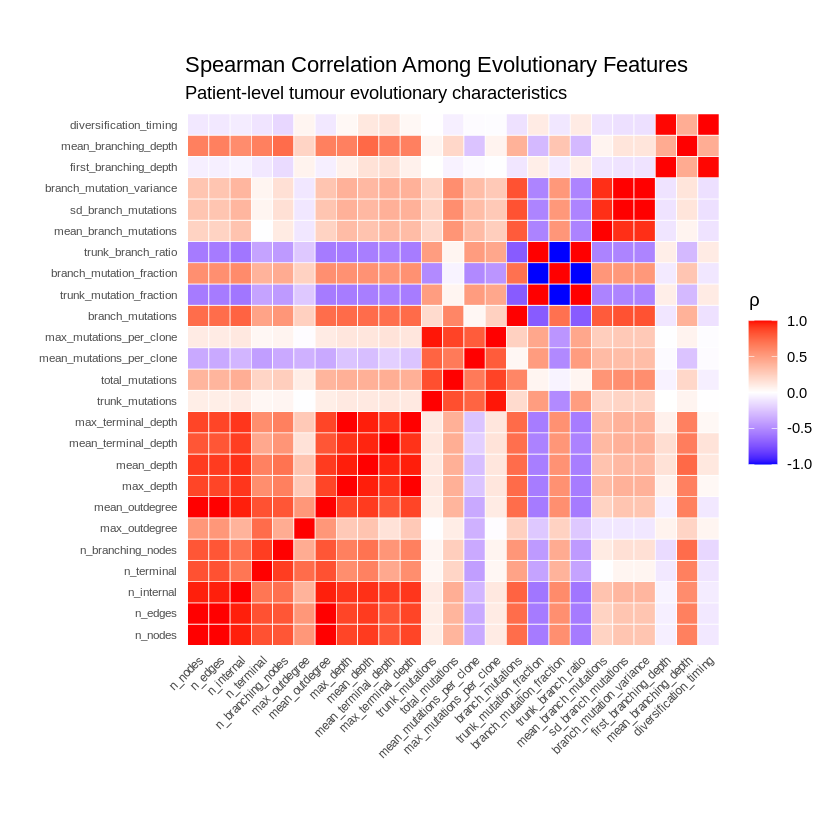

In [22]:
# ============================================================
# SPEARMAN CORRELATION ANALYSIS
# Do evolutionary features capture related but
# non-redundant properties?
# ============================================================

# Install packages if needed
packages <- c("ggplot2", "dplyr", "tidyr", "Hmisc")

for (p in packages) {
  if (!requireNamespace(p, quietly = TRUE)) {
    install.packages(p)
  }
}

library(ggplot2)
library(dplyr)
library(tidyr)
library(Hmisc)


# ============================================================
# 1. PREPARE NUMERIC FEATURES
# ============================================================

cor_features <- patient_level_feature_matrix %>%
  select(-patient_id) %>%
  select(where(is.numeric))

cat("Number of features:", ncol(cor_features), "\n")
cat("Number of patients:", nrow(cor_features), "\n")


# ============================================================
# 2. SPEARMAN CORRELATION + P-VALUES
# ============================================================

spearman_result <- Hmisc::rcorr(
  as.matrix(cor_features),
  type = "spearman"
)

# Correlation matrix
cor_matrix <- spearman_result$r

# Raw p-value matrix
p_matrix <- spearman_result$P


# ============================================================
# 3. FDR CORRECTION
# ============================================================

# Extract unique feature pairs only
upper_idx <- upper.tri(cor_matrix)

feature1 <- rownames(cor_matrix)[
  row(cor_matrix)[upper_idx]
]

feature2 <- colnames(cor_matrix)[
  col(cor_matrix)[upper_idx]
]

rho_values <- cor_matrix[upper_idx]

p_values <- p_matrix[upper_idx]

# Benjamini-Hochberg FDR correction
fdr_values <- p.adjust(
  p_values,
  method = "BH"
)

correlation_pairs <- data.frame(
  Feature_1 = feature1,
  Feature_2 = feature2,
  Spearman_rho = rho_values,
  P_value = p_values,
  FDR_adjusted_p = fdr_values
)

# Absolute correlation for ranking
correlation_pairs$Absolute_rho <-
  abs(correlation_pairs$Spearman_rho)

# Sort strongest first
correlation_pairs <- correlation_pairs %>%
  arrange(desc(Absolute_rho))


# ============================================================
# 4. STRONGLY CORRELATED FEATURE PAIRS
# |rho| > 0.70
# ============================================================

strong_correlations <- correlation_pairs %>%
  filter(
    Absolute_rho > 0.70
  )

cat("\nStrongly correlated feature pairs (|rho| > 0.70):\n")

print(
  strong_correlations
)


# ============================================================
# 5. TOP FEATURE ASSOCIATIONS
# Table 4.3
# ============================================================

top_correlations <- correlation_pairs %>%
  slice_head(n = 10) %>%
  select(
    Feature_1,
    Feature_2,
    Spearman_rho,
    FDR_adjusted_p
  )

print(top_correlations)


# ============================================================
# 6. PREPARE DATA FOR 25 x 25 HEATMAP
# ============================================================

cor_heatmap_df <- as.data.frame(
  as.table(cor_matrix)
)

colnames(cor_heatmap_df) <- c(
  "Feature1",
  "Feature2",
  "Spearman_rho"
)


# ============================================================
# 7. SPEARMAN CORRELATION HEATMAP
# ============================================================

spearman_heatmap <- ggplot(
  cor_heatmap_df,
  aes(
    x = Feature1,
    y = Feature2,
    fill = Spearman_rho
  )
) +
  geom_tile(
    color = "white",
    linewidth = 0.2
  ) +

  scale_fill_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    midpoint = 0,
    limits = c(-1, 1)
  ) +

  labs(
    title = "Spearman Correlation Among Evolutionary Features",
    subtitle = "Patient-level tumour evolutionary characteristics",
    x = NULL,
    y = NULL,
    fill = expression(rho)
  ) +

  coord_fixed() +

  theme_minimal() +

  theme(
    panel.grid = element_blank(),

    axis.text.x = element_text(
      angle = 45,
      hjust = 1,
      size = 7
    ),

    axis.text.y = element_text(
      size = 7
    )
  )

print(spearman_heatmap)


# ============================================================
# 8. SAVE FIGURE 4.3
# ============================================================

ggsave(
  filename = "Figure_4_3_Spearman_correlation_heatmap.png",
  plot = spearman_heatmap,
  width = 11,
  height = 10,
  dpi = 600
)

ggsave(
  filename = "Figure_4_3_Spearman_correlation_heatmap.pdf",
  plot = spearman_heatmap,
  width = 11,
  height = 10
)


# ============================================================
# 9. SAVE TABLES
# ============================================================

# Full pairwise correlation results
write.csv(
  correlation_pairs,
  "Spearman_all_feature_pairs.csv",
  row.names = FALSE
)

# Strong correlations only
write.csv(
  strong_correlations,
  "Table_4_3_strong_feature_associations.csv",
  row.names = FALSE
)

# Top 10 associations
write.csv(
  top_correlations,
  "Top_10_Spearman_feature_associations.csv",
  row.names = FALSE
)

# Full correlation matrix
write.csv(
  cor_matrix,
  "Spearman_correlation_matrix.csv",
  row.names = TRUE
)

cat("\nSpearman correlation analysis completed successfully.\n")

Number of patients: 398 
Number of evolutionary features: 25 
Missing values: 83 
Non-finite values: 83 

Features used for correlation: 25 

ALL SPEARMAN CORRELATION PAIRS
                   Feature_1                Feature_2 Spearman_rho      P_value
1                    n_nodes                  n_edges  1.000000000 0.000000e+00
2                    n_nodes           mean_outdegree  1.000000000 0.000000e+00
3                    n_edges           mean_outdegree  1.000000000 0.000000e+00
4                  max_depth       max_terminal_depth  1.000000000 0.000000e+00
5    trunk_mutation_fraction branch_mutation_fraction -1.000000000 0.000000e+00
6    trunk_mutation_fraction       trunk_branch_ratio  1.000000000 0.000000e+00
7   branch_mutation_fraction       trunk_branch_ratio -1.000000000 0.000000e+00
8        sd_branch_mutations branch_mutation_variance  1.000000000 0.000000e+00
9      first_branching_depth   diversification_timing  0.995778614 0.000000e+00
10           trunk_mutation



Table: Strong associations among evolutionary features (|rho| > 0.70)

|Feature 1                |Feature 2                | Spearman rho | FDR-adjusted p |
|:------------------------|:------------------------|:------------:|:--------------:|
|n_nodes                  |n_edges                  |    1.000     |     <0.001     |
|n_nodes                  |mean_outdegree           |    1.000     |     <0.001     |
|n_edges                  |mean_outdegree           |    1.000     |     <0.001     |
|max_depth                |max_terminal_depth       |    1.000     |     <0.001     |
|trunk_mutation_fraction  |branch_mutation_fraction |    -1.000    |     <0.001     |
|trunk_mutation_fraction  |trunk_branch_ratio       |    1.000     |     <0.001     |
|branch_mutation_fraction |trunk_branch_ratio       |    -1.000    |     <0.001     |
|sd_branch_mutations      |branch_mutation_variance |    1.000     |     <0.001     |
|first_branching_depth    |diversification_timing   |    0.996     


TOP 10 FEATURE ASSOCIATIONS





Table: Top 10 Spearman correlations among evolutionary features

|Feature 1                |Feature 2                | Spearman rho | FDR-adjusted p |
|:------------------------|:------------------------|:------------:|:--------------:|
|n_nodes                  |n_edges                  |    1.000     |     <0.001     |
|n_nodes                  |mean_outdegree           |    1.000     |     <0.001     |
|n_edges                  |mean_outdegree           |    1.000     |     <0.001     |
|max_depth                |max_terminal_depth       |    1.000     |     <0.001     |
|trunk_mutation_fraction  |branch_mutation_fraction |    -1.000    |     <0.001     |
|trunk_mutation_fraction  |trunk_branch_ratio       |    1.000     |     <0.001     |
|branch_mutation_fraction |trunk_branch_ratio       |    -1.000    |     <0.001     |
|sd_branch_mutations      |branch_mutation_variance |    1.000     |     <0.001     |
|first_branching_depth    |diversification_timing   |    0.996     |     


SPEARMAN CORRELATION ANALYSIS COMPLETE
Number of features analyzed: 25 
Total unique feature pairs: 300 
Strongly correlated pairs |rho| > 0.70: 66 

Results and figures saved successfully.


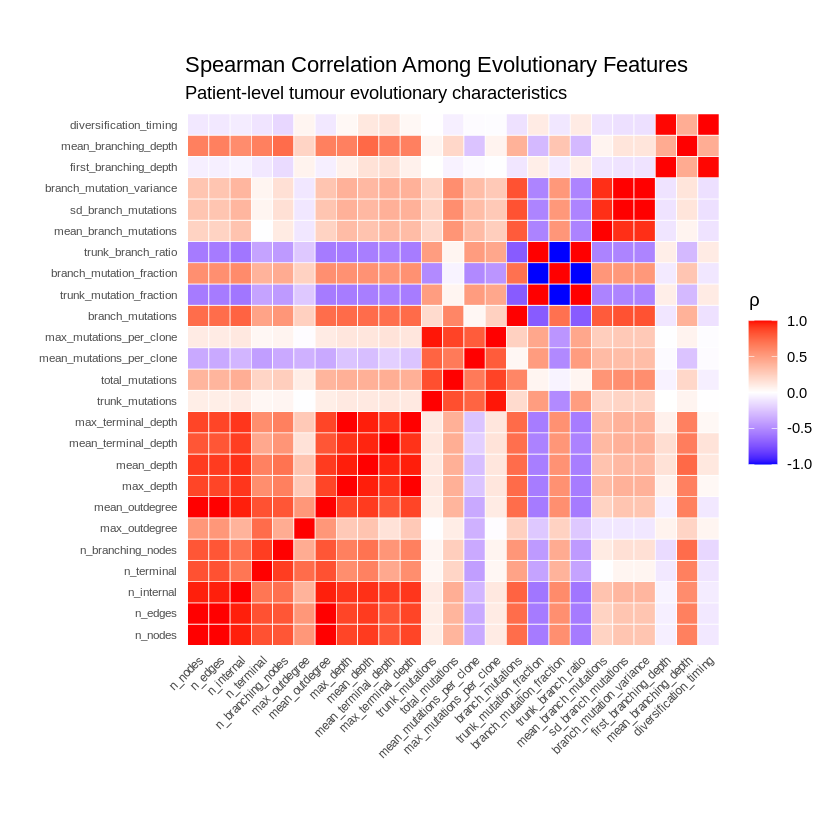

In [23]:
# ============================================================
# SPEARMAN CORRELATION ANALYSIS
# Evolutionary features capture related but
# non-redundant properties
# ============================================================


# ============================================================
# 0. INSTALL AND LOAD REQUIRED PACKAGES
# ============================================================

packages <- c(
  "ggplot2",
  "dplyr",
  "tidyr",
  "Hmisc",
  "knitr"
)

for (p in packages) {
  if (!requireNamespace(p, quietly = TRUE)) {
    install.packages(p)
  }
}

library(ggplot2)
library(dplyr)
library(tidyr)
library(Hmisc)
library(knitr)


# ============================================================
# 1. PREPARE NUMERIC EVOLUTIONARY FEATURES
# ============================================================

cor_features <- patient_level_feature_matrix %>%
  select(-patient_id) %>%
  select(where(is.numeric))


cat(
  "Number of patients:",
  nrow(cor_features),
  "\n"
)

cat(
  "Number of evolutionary features:",
  ncol(cor_features),
  "\n"
)


# ============================================================
# 2. CHECK MISSING AND NON-FINITE VALUES
# ============================================================

cat(
  "Missing values:",
  sum(is.na(cor_features)),
  "\n"
)

cat(
  "Non-finite values:",
  sum(!is.finite(as.matrix(cor_features))),
  "\n"
)


# Convert Inf/-Inf to NA
cor_features[] <- lapply(
  cor_features,
  function(x) {
    x[is.infinite(x)] <- NA
    x
  }
)


# ============================================================
# 3. REMOVE FEATURES WITH NO VARIATION
# ============================================================

keep_features <- sapply(
  cor_features,
  function(x) {

    values <- x[!is.na(x)]

    length(values) > 1 &&
      length(unique(values)) > 1
  }
)

if (any(!keep_features)) {

  cat(
    "\nRemoved constant/non-informative features:\n"
  )

  print(
    names(cor_features)[!keep_features]
  )
}

cor_features <- cor_features[
  ,
  keep_features,
  drop = FALSE
]


cat(
  "\nFeatures used for correlation:",
  ncol(cor_features),
  "\n"
)


# ============================================================
# 4. SPEARMAN CORRELATION
# ============================================================

spearman_result <- Hmisc::rcorr(
  as.matrix(cor_features),
  type = "spearman"
)


# Correlation matrix
cor_matrix <- spearman_result$r

# Raw p-value matrix
p_matrix <- spearman_result$P


# ============================================================
# 5. EXTRACT UNIQUE FEATURE PAIRS
# ============================================================

upper_index <- upper.tri(
  cor_matrix,
  diag = FALSE
)

row_index <- row(cor_matrix)[upper_index]

col_index <- col(cor_matrix)[upper_index]


correlation_pairs <- data.frame(

  Feature_1 =
    rownames(cor_matrix)[row_index],

  Feature_2 =
    colnames(cor_matrix)[col_index],

  Spearman_rho =
    cor_matrix[upper_index],

  P_value =
    p_matrix[upper_index]
)


# ============================================================
# 6. FDR CORRECTION
# Benjamini-Hochberg method
# ============================================================

correlation_pairs$FDR_adjusted_p <- p.adjust(
  correlation_pairs$P_value,
  method = "BH"
)


# Calculate absolute rho
correlation_pairs$Absolute_rho <- abs(
  correlation_pairs$Spearman_rho
)


# Sort strongest correlations first
correlation_pairs <- correlation_pairs %>%
  arrange(
    desc(Absolute_rho)
  )


# ============================================================
# 7. DISPLAY ALL CORRELATION RESULTS
# ============================================================

cat(
  "\n========================================\n"
)

cat(
  "ALL SPEARMAN CORRELATION PAIRS\n"
)

cat(
  "========================================\n"
)

print(
  correlation_pairs
)


# ============================================================
# 8. IDENTIFY STRONGLY CORRELATED FEATURES
# Threshold: |rho| > 0.70
# ============================================================

strong_correlations <- correlation_pairs %>%

  filter(
    Absolute_rho > 0.70
  )


cat(
  "\n========================================\n"
)

cat(
  "STRONG CORRELATIONS |rho| > 0.70\n"
)

cat(
  "========================================\n"
)

print(
  strong_correlations
)


# ============================================================
# 9. CREATE CLEAN TABLE 4.3
# ============================================================

strong_table <- strong_correlations %>%

  mutate(

    Spearman_rho =
      round(
        Spearman_rho,
        3
      ),

    FDR_adjusted_p =
      ifelse(
        FDR_adjusted_p < 0.001,
        "<0.001",
        sprintf(
          "%.3f",
          FDR_adjusted_p
        )
      )

  ) %>%

  select(
    Feature_1,
    Feature_2,
    Spearman_rho,
    FDR_adjusted_p
  )


# ============================================================
# 10. DISPLAY TABLE 4.3
# ============================================================

cat(
  "\n========================================\n"
)

cat(
  "TABLE 4.3: STRONGEST FEATURE ASSOCIATIONS\n"
)

cat(
  "========================================\n\n"
)


knitr::kable(

  strong_table,

  caption =
    "Strong associations among evolutionary features (|rho| > 0.70)",

  col.names = c(
    "Feature 1",
    "Feature 2",
    "Spearman rho",
    "FDR-adjusted p"
  ),

  align = c(
    "l",
    "l",
    "c",
    "c"
  )
)


# ============================================================
# 11. CREATE TOP 10 ASSOCIATIONS TABLE
# ============================================================

top10_table <- correlation_pairs %>%

  slice_head(
    n = 10
  ) %>%

  mutate(

    Spearman_rho =
      round(
        Spearman_rho,
        3
      ),

    FDR_adjusted_p =
      ifelse(
        FDR_adjusted_p < 0.001,
        "<0.001",
        sprintf(
          "%.3f",
          FDR_adjusted_p
        )
      )

  ) %>%

  select(
    Feature_1,
    Feature_2,
    Spearman_rho,
    FDR_adjusted_p
  )


cat(
  "\n========================================\n"
)

cat(
  "TOP 10 FEATURE ASSOCIATIONS\n"
)

cat(
  "========================================\n\n"
)


knitr::kable(

  top10_table,

  caption =
    "Top 10 Spearman correlations among evolutionary features",

  col.names = c(
    "Feature 1",
    "Feature 2",
    "Spearman rho",
    "FDR-adjusted p"
  ),

  align = c(
    "l",
    "l",
    "c",
    "c"
  )
)


# ============================================================
# 12. PREPARE CORRELATION MATRIX FOR HEATMAP
# ============================================================

cor_heatmap_df <- as.data.frame(
  as.table(cor_matrix)
)

colnames(
  cor_heatmap_df
) <- c(
  "Feature1",
  "Feature2",
  "Spearman_rho"
)


# ============================================================
# 13. CREATE 25 x 25 SPEARMAN HEATMAP
# ============================================================

spearman_heatmap <- ggplot(

  cor_heatmap_df,

  aes(
    x = Feature1,
    y = Feature2,
    fill = Spearman_rho
  )

) +

  geom_tile(
    color = "white",
    linewidth = 0.2
  ) +

  scale_fill_gradient2(

    low = "blue",

    mid = "white",

    high = "red",

    midpoint = 0,

    limits = c(
      -1,
      1
    )

  ) +

  labs(

    title =
      "Spearman Correlation Among Evolutionary Features",

    subtitle =
      "Patient-level tumour evolutionary characteristics",

    x = NULL,

    y = NULL,

    fill = expression(rho)

  ) +

  coord_fixed() +

  theme_minimal() +

  theme(

    panel.grid =
      element_blank(),

    axis.text.x =
      element_text(
        angle = 45,
        hjust = 1,
        size = 7
      ),

    axis.text.y =
      element_text(
        size = 7
      )

  )


# Display heatmap
print(
  spearman_heatmap
)


# ============================================================
# 14. SAVE HEATMAP
# ============================================================

ggsave(

  filename =
    "Figure_4_3_Spearman_correlation_heatmap.png",

  plot =
    spearman_heatmap,

  width = 11,

  height = 10,

  dpi = 600

)


ggsave(

  filename =
    "Figure_4_3_Spearman_correlation_heatmap.pdf",

  plot =
    spearman_heatmap,

  width = 11,

  height = 10

)


# ============================================================
# 15. SAVE TABLE 4.3
# ============================================================

write.csv(

  strong_table,

  "Table_4_3_Strong_Spearman_Associations.csv",

  row.names = FALSE

)


# ============================================================
# 16. SAVE TOP 10 ASSOCIATIONS
# ============================================================

write.csv(

  top10_table,

  "Top_10_Spearman_Feature_Associations.csv",

  row.names = FALSE

)


# ============================================================
# 17. SAVE ALL PAIRWISE RESULTS
# ============================================================

write.csv(

  correlation_pairs,

  "Spearman_All_Feature_Pairs.csv",

  row.names = FALSE

)


# ============================================================
# 18. SAVE FULL CORRELATION MATRIX
# ============================================================

write.csv(

  round(
    cor_matrix,
    4
  ),

  "Spearman_Correlation_Matrix.csv",

  row.names = TRUE

)


# ============================================================
# 19. SUMMARY
# ============================================================

cat(
  "\n========================================\n"
)

cat(
  "SPEARMAN CORRELATION ANALYSIS COMPLETE\n"
)

cat(
  "========================================\n"
)

cat(
  "Number of features analyzed:",
  ncol(cor_features),
  "\n"
)

cat(
  "Total unique feature pairs:",
  nrow(correlation_pairs),
  "\n"
)

cat(
  "Strongly correlated pairs |rho| > 0.70:",
  nrow(strong_correlations),
  "\n"
)

cat(
  "\nResults and figures saved successfully.\n"
)

In [26]:
# ============================================================
# CHECK MISSING, INVALID, AND ZERO-VARIANCE FEATURES
# ============================================================

library(dplyr)

# ------------------------------------------------------------
# 1. Select numeric features only
# ------------------------------------------------------------

numeric_features <- patient_level_feature_matrix %>%
  select(-patient_id)


# ------------------------------------------------------------
# 2. Check missing values
# ------------------------------------------------------------

cat("Missing values per feature:\n")
print(colSums(is.na(numeric_features)))


# ------------------------------------------------------------
# 3. Check invalid values: Inf / -Inf
# ------------------------------------------------------------

cat("\nInfinite values per feature:\n")

print(
  sapply(
    numeric_features,
    function(x) sum(is.infinite(x))
  )
)


# ------------------------------------------------------------
# 4. Check number of unique values
# ------------------------------------------------------------

cat("\nNumber of unique values per feature:\n")

unique_counts <- sapply(
  numeric_features,
  function(x) length(unique(x[!is.na(x)]))
)

print(unique_counts)


# ------------------------------------------------------------
# 5. Identify and remove zero-variance features
# ------------------------------------------------------------

keep_feature <- sapply(
  numeric_features,
  function(x) {
    v <- var(x, na.rm = TRUE)
    !is.na(v) && v > 0
  }
)

cat("\nFeatures removed because of zero variance:\n")
print(names(keep_feature)[!keep_feature])


# Keep only informative features
numeric_features_clean <- numeric_features[, keep_feature, drop = FALSE]


# ------------------------------------------------------------
# 6. Final dimensions
# ------------------------------------------------------------

cat(
  "\nBefore removing zero-variance features:",
  ncol(numeric_features), "features\n"
)

cat(
  "After removing zero-variance features:",
  ncol(numeric_features_clean), "features\n"
)

numeric_features <-
  numeric_features[, keep_feature]

Missing values per feature:
                 n_nodes                  n_edges               n_internal 
                       0                        0                        0 
              n_terminal        n_branching_nodes            max_outdegree 
                       0                        0                        0 
          mean_outdegree                max_depth               mean_depth 
                       0                        0                        0 
     mean_terminal_depth       max_terminal_depth          trunk_mutations 
                       0                        0                        0 
         total_mutations mean_mutations_per_clone  max_mutations_per_clone 
                       0                        0                        0 
        branch_mutations  trunk_mutation_fraction branch_mutation_fraction 
                       0                        0                        0 
      trunk_branch_ratio    mean_branch_mutations      sd_br

In [27]:
# ============================================================
# FEATURE NORMALIZATION
# ============================================================

# Features are measured on very different scales.
# For example, clone count may be around 5,
# while mutation counts may be in the hundreds.
#
# Therefore, standardize all numeric features
# before distance calculation and clustering.

scaled_features <- scale(
  numeric_features_clean
)

# Convert back to data frame
scaled_features <- as.data.frame(
  scaled_features
)

# Keep patient IDs as row names
rownames(scaled_features) <-
  patient_level_feature_matrix$patient_id


# Inspect the normalized feature matrix
cat(
  "Scaled feature matrix:",
  nrow(scaled_features), "patients x",
  ncol(scaled_features), "features\n"
)

head(scaled_features)

Scaled feature matrix: 398 patients x 25 features


,n_nodes,n_edges,n_internal,n_terminal,n_branching_nodes,max_outdegree,mean_outdegree,max_depth,mean_depth,mean_terminal_depth,⋯,branch_mutations,trunk_mutation_fraction,branch_mutation_fraction,trunk_branch_ratio,mean_branch_mutations,sd_branch_mutations,branch_mutation_variance,first_branching_depth,mean_branching_depth,diversification_timing
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CRUK0005,0.7821399,0.7821399,0.93423686,0.2341473,0.71336478,-0.4481501,0.77319903,1.5719538,2.0089197,1.4797496,⋯,1.7048751,-1.9947853,1.9947853,-0.5421698,1.5237784,2.0818818,0.8332621,-0.4185806,1.4898692,-0.4055647
CRUK0057,-0.7049223,-0.7049223,-0.59142779,-0.8129383,-0.76924192,-0.4481501,-0.30328658,-0.6079682,-0.7219217,-0.5232661,⋯,-0.3484153,1.0935255,-1.0935255,0.4699335,-0.1832477,-0.2648742,-0.1792919,-0.4185806,-1.0889432,-0.4055647
CRUK0039,-0.8701514,-0.8701514,-0.80937988,-0.8129383,-0.76924192,-0.4481501,-0.66211511,-1.1529487,-1.0586008,-0.9238692,⋯,-0.3764245,1.1262476,-1.1262476,0.5686283,-0.1137757,-0.2038957,-0.1732980,-0.4185806,-1.0889432,-0.4055647
CRUK0196,-0.5396932,-0.5396932,-0.59142779,-0.2893955,-0.02793857,-0.4481501,-0.04698048,-0.6079682,-0.4814367,-0.3897317,⋯,-0.4281338,1.0735671,-1.0735671,0.4170577,-0.4927138,-0.4549258,-0.1910192,-0.4185806,0.2004630,-0.4055647
CRUK0023,0.1212234,0.1212234,0.06242849,0.2341473,-0.02793857,0.6736344,0.51223282,-0.0629877,-0.1607899,-0.3229645,⋯,-0.3010151,-0.1188272,0.1188272,-0.3859021,-0.4579778,-0.3901999,-0.1882076,-0.4185806,-0.4442401,-0.4055647
CRUK0050,-1.0353806,-1.0353806,-1.02733197,-0.8129383,-0.76924192,-0.4481501,-1.20035792,-1.1529487,-1.0024876,-0.9238692,⋯,-0.5380161,1.0424193,-1.0424193,0.3436213,-0.6506047,-0.5353993,-0.1928116,1.6045588,0.2004630,3.5203271


In [28]:
head(scaled_features)

,n_nodes,n_edges,n_internal,n_terminal,n_branching_nodes,max_outdegree,mean_outdegree,max_depth,mean_depth,mean_terminal_depth,⋯,branch_mutations,trunk_mutation_fraction,branch_mutation_fraction,trunk_branch_ratio,mean_branch_mutations,sd_branch_mutations,branch_mutation_variance,first_branching_depth,mean_branching_depth,diversification_timing
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CRUK0005,0.7821399,0.7821399,0.93423686,0.2341473,0.71336478,-0.4481501,0.77319903,1.5719538,2.0089197,1.4797496,⋯,1.7048751,-1.9947853,1.9947853,-0.5421698,1.5237784,2.0818818,0.8332621,-0.4185806,1.4898692,-0.4055647
CRUK0057,-0.7049223,-0.7049223,-0.59142779,-0.8129383,-0.76924192,-0.4481501,-0.30328658,-0.6079682,-0.7219217,-0.5232661,⋯,-0.3484153,1.0935255,-1.0935255,0.4699335,-0.1832477,-0.2648742,-0.1792919,-0.4185806,-1.0889432,-0.4055647
CRUK0039,-0.8701514,-0.8701514,-0.80937988,-0.8129383,-0.76924192,-0.4481501,-0.66211511,-1.1529487,-1.0586008,-0.9238692,⋯,-0.3764245,1.1262476,-1.1262476,0.5686283,-0.1137757,-0.2038957,-0.1732980,-0.4185806,-1.0889432,-0.4055647
CRUK0196,-0.5396932,-0.5396932,-0.59142779,-0.2893955,-0.02793857,-0.4481501,-0.04698048,-0.6079682,-0.4814367,-0.3897317,⋯,-0.4281338,1.0735671,-1.0735671,0.4170577,-0.4927138,-0.4549258,-0.1910192,-0.4185806,0.2004630,-0.4055647
CRUK0023,0.1212234,0.1212234,0.06242849,0.2341473,-0.02793857,0.6736344,0.51223282,-0.0629877,-0.1607899,-0.3229645,⋯,-0.3010151,-0.1188272,0.1188272,-0.3859021,-0.4579778,-0.3901999,-0.1882076,-0.4185806,-0.4442401,-0.4055647
CRUK0050,-1.0353806,-1.0353806,-1.02733197,-0.8129383,-0.76924192,-0.4481501,-1.20035792,-1.1529487,-1.0024876,-0.9238692,⋯,-0.5380161,1.0424193,-1.0424193,0.3436213,-0.6506047,-0.5353993,-0.1928116,1.6045588,0.2004630,3.5203271


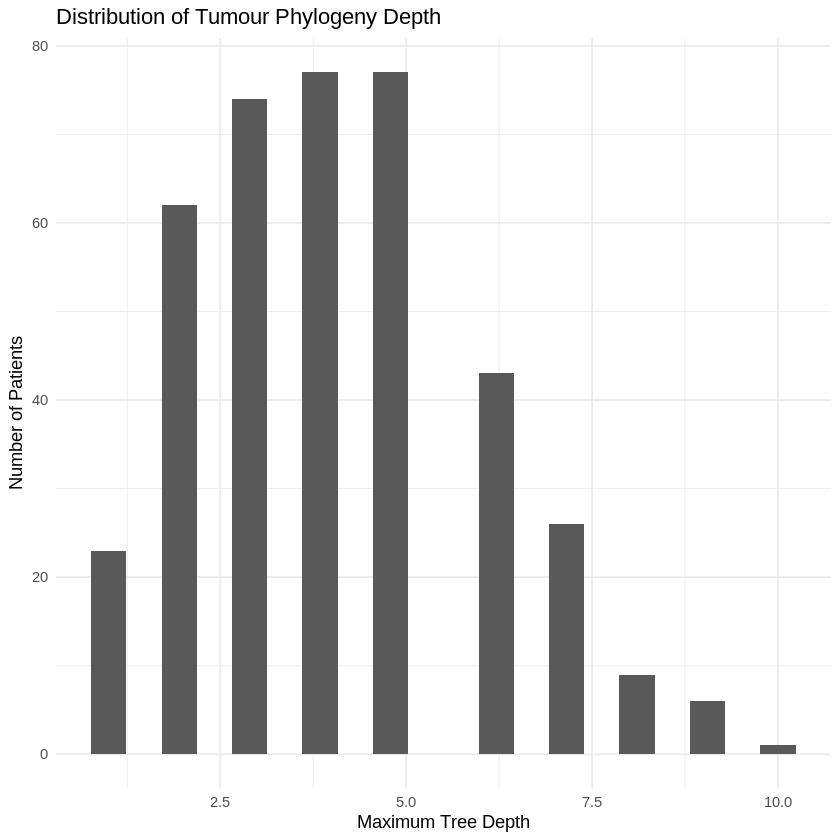

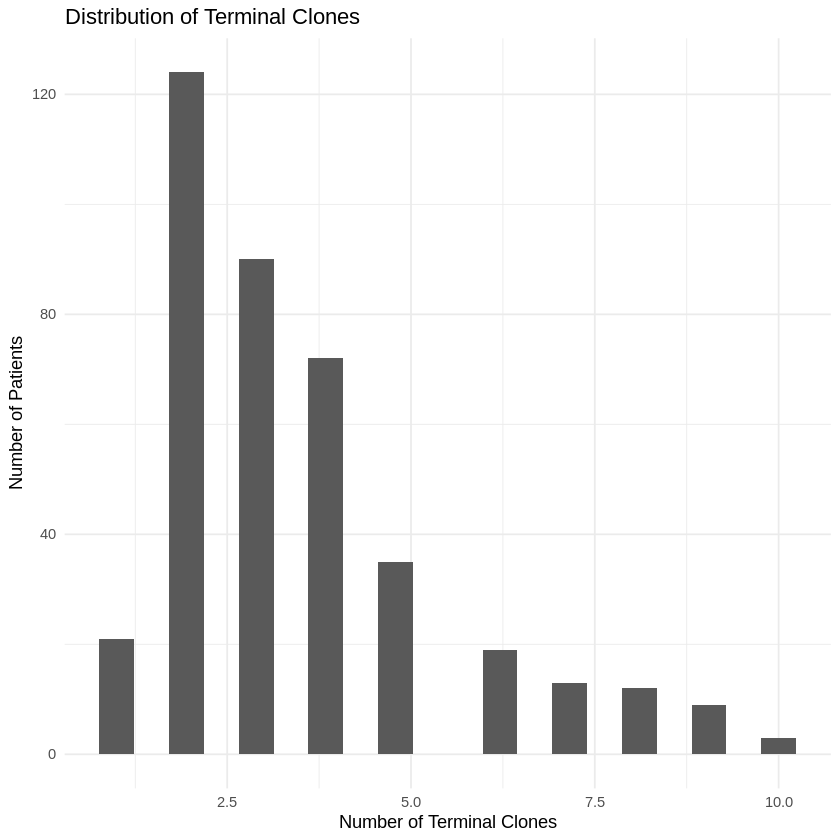

In [29]:
# ============================================================
# EXPLORE PATIENT-LEVEL FEATURE DISTRIBUTIONS
# ============================================================

library(ggplot2)
library(dplyr)

# Before clustering, inspect whether tumour phylogeny
# characteristics vary across patients.


# ------------------------------------------------------------
# 1. Distribution of maximum tree depth
# ------------------------------------------------------------

patient_level_feature_matrix %>%
  ggplot(
    aes(x = max_depth)
  ) +
  geom_histogram(
    bins = 20
  ) +
  labs(
    title = "Distribution of Tumour Phylogeny Depth",
    x = "Maximum Tree Depth",
    y = "Number of Patients"
  ) +
  theme_minimal()


# ------------------------------------------------------------
# 2. Distribution of terminal clones
# ------------------------------------------------------------

patient_level_feature_matrix %>%
  ggplot(
    aes(x = n_terminal)
  ) +
  geom_histogram(
    bins = 20
  ) +
  labs(
    title = "Distribution of Terminal Clones",
    x = "Number of Terminal Clones",
    y = "Number of Patients"
  ) +
  theme_minimal()

Warning message:
“Removed 21 rows containing non-finite outside the scale range (`stat_bin()`).”


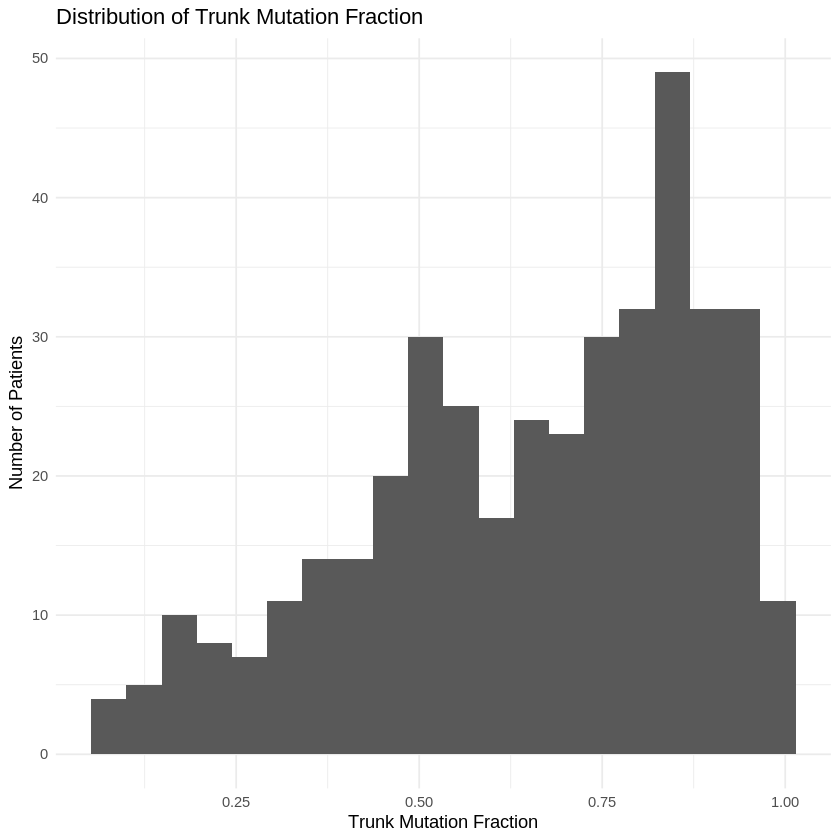

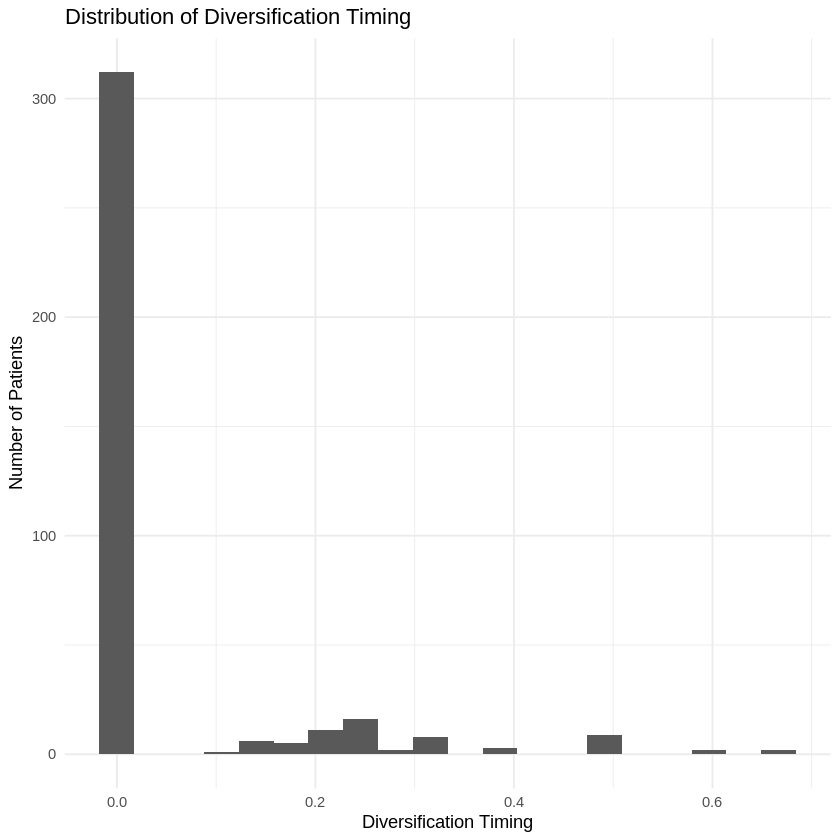

In [30]:
# ------------------------------------------------------------
# 3. Distribution of trunk mutation fraction
# ------------------------------------------------------------

patient_level_feature_matrix %>%
  ggplot(
    aes(x = trunk_mutation_fraction)
  ) +
  geom_histogram(
    bins = 20
  ) +
  labs(
    title = "Distribution of Trunk Mutation Fraction",
    x = "Trunk Mutation Fraction",
    y = "Number of Patients"
  ) +
  theme_minimal()


# ------------------------------------------------------------
# 4. Distribution of diversification timing
# ------------------------------------------------------------

patient_level_feature_matrix %>%
  ggplot(
    aes(x = diversification_timing)
  ) +
  geom_histogram(
    bins = 20
  ) +
  labs(
    title = "Distribution of Diversification Timing",
    x = "Diversification Timing",
    y = "Number of Patients"
  ) +
  theme_minimal()

In [31]:
# ============================================================
# CROSS-PATIENT COMPARATIVE ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. Calculate patient-to-patient Euclidean distance
# ------------------------------------------------------------

patient_distance <- dist(
  scaled_features,
  method = "euclidean"
)

# Convert distance object to matrix
patient_distance_matrix <- as.matrix(
  patient_distance
)

cat(
  "Patient distance matrix:",
  nrow(patient_distance_matrix), "x",
  ncol(patient_distance_matrix), "\n"
)

# Inspect first few patients
patient_distance_matrix[1:5, 1:5]

Patient distance matrix: 398 x 398 


,CRUK0005,CRUK0057,CRUK0039,CRUK0196,CRUK0023
CRUK0005,0.000000,8.871980,9.551672,8.099342,6.721262
CRUK0057,8.871980,0.000000,1.122797,2.398520,4.674931
CRUK0039,9.551672,1.122797,0.000000,2.841426,5.227132
CRUK0196,8.099342,2.398520,2.841426,0.000000,3.249376
CRUK0023,6.721262,4.674931,5.227132,3.249376,0.000000


In [32]:
# ============================================================
# CHECK MISSING VALUES IN SCALED FEATURES
# ============================================================

cat("Total missing values:",
    sum(is.na(scaled_features)), "\n")

cat("Features containing missing values:\n")

print(
  colSums(is.na(scaled_features))[
    colSums(is.na(scaled_features)) > 0
  ]
)

cat("\nPatients containing missing values:\n")

print(
  rowSums(is.na(scaled_features))[
    rowSums(is.na(scaled_features)) > 0
  ]
)

Total missing values: 83 
Features containing missing values:
     sd_branch_mutations branch_mutation_variance    first_branching_depth 
                      10                       10                       21 
    mean_branching_depth   diversification_timing 
                      21                       21 

Patients containing missing values:
CRUK0721_Tumour1         CRUK0061         CRUK0312         CRUK0359 
               3                5                5                3 
        CRUK0334         CRUK0033         CRUK0503         CRUK0092 
               3                5                5                5 
        CRUK0091         CRUK0124         CRUK0059         CRUK0118 
               3                5                5                3 
        CRUK0142         CRUK0232 CRUK0372_Tumour2         CRUK0371 
               5                3                5                3 
        CRUK0566         CRUK0636         CRUK0861 CRUK0555_Tumour1 
               3          

In [33]:
# ============================================================
# HANDLE MISSING VALUES BEFORE NORMALIZATION
# ============================================================

# Start from cleaned numeric features
numeric_features_imputed <- numeric_features_clean


# Median imputation for each feature
numeric_features_imputed[] <- lapply(
  numeric_features_imputed,
  function(x) {

    if (any(is.na(x))) {

      x[is.na(x)] <- median(
        x,
        na.rm = TRUE
      )

    }

    x
  }
)


# Check again
cat(
  "Remaining missing values:",
  sum(is.na(numeric_features_imputed)),
  "\n"
)

Remaining missing values: 0 


In [34]:
cat(
  "Infinite values:",
  sum(
    sapply(
      numeric_features_imputed,
      function(x) sum(is.infinite(x))
    )
  ),
  "\n"
)

Infinite values: 0 


In [35]:
# ============================================================
# STANDARDIZE CLEAN FEATURES
# ============================================================

scaled_features <- scale(
  numeric_features_imputed
)

scaled_features <- as.data.frame(
  scaled_features
)

rownames(scaled_features) <-
  patient_level_feature_matrix$patient_id


# Final safety check
cat(
  "NA values after scaling:",
  sum(is.na(scaled_features)),
  "\n"
)

cat(
  "Infinite values after scaling:",
  sum(!is.finite(as.matrix(scaled_features))),
  "\n"
)

NA values after scaling: 0 
Infinite values after scaling: 0 


In [ ]:
# ============================================================
# UMAP: NONLINEAR VISUALIZATION OF PATIENTS
# ============================================================

# Install once if needed
if (!requireNamespace("uwot", quietly = TRUE)) {
  install.packages("uwot")
}

library(uwot)
library(ggplot2)

# ------------------------------------------------------------
# 1. Run UMAP
# ------------------------------------------------------------

set.seed(123)

umap_result <- umap(
  scaled_features,
  n_neighbors = 15,
  min_dist = 0.1,
  n_components = 2,
  metric = "euclidean"
)


# ------------------------------------------------------------
# 2. Create UMAP data frame
# ------------------------------------------------------------

umap_df <- data.frame(
  patient_id = rownames(scaled_features),
  UMAP1 = umap_result[, 1],
  UMAP2 = umap_result[, 2]
)

head(umap_df)


# ------------------------------------------------------------
# 3. Plot UMAP
# ------------------------------------------------------------

ggplot(
  umap_df,
  aes(
    x = UMAP1,
    y = UMAP2
  )
) +
  geom_point(
    size = 2,
    alpha = 0.7
  ) +
  labs(
    title = "UMAP of Patient Evolutionary Profiles",
    x = "UMAP 1",
    y = "UMAP 2"
  ) +
  theme_minimal()

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppEigen’, ‘BH’, ‘sitmo’, ‘FNN’, ‘irlba’, ‘RcppAnnoy’, ‘RSpectra’, ‘dqrng’, ‘RcppProgress’




In [ ]:
# ============================================================
# COLOR UMAP BY PATIENT CLUSTERS
# ============================================================

# ------------------------------------------------------------
# 1. K-means clustering
# ------------------------------------------------------------

set.seed(123)

kmeans_result <- kmeans(
  scaled_features,
  centers = 3,
  nstart = 50
)

# Add cluster labels to UMAP data
umap_df$cluster <- factor(
  kmeans_result$cluster
)


# ------------------------------------------------------------
# 2. Create UMAP plot
# ------------------------------------------------------------

umap_cluster_plot <- ggplot(
  umap_df,
  aes(
    x = UMAP1,
    y = UMAP2,
    color = cluster
  )
) +
  geom_point(
    size = 3,
    alpha = 0.8
  ) +
  labs(
    title = "UMAP of Patient Evolutionary Profiles",
    subtitle = "Patients Colored by Cluster",
    x = "UMAP 1",
    y = "UMAP 2",
    color = "Cluster"
  ) +
  theme_minimal()


# Display plot
umap_cluster_plot


# ------------------------------------------------------------
# 3. Save plot
# ------------------------------------------------------------

ggsave(
  filename = "UMAP_patient_clusters.png",
  plot = umap_cluster_plot,
  width = 7,
  height = 6,
  dpi = 600
)

ggsave(
  filename = "UMAP_patient_clusters.pdf",
  plot = umap_cluster_plot,
  width = 7,
  height = 6
)

cat("UMAP plots saved successfully.\n")

In [ ]:
# ============================================================
# SILHOUETTE ANALYSIS
# Determine optimal number of evolutionary pattern groups
# ============================================================

# Install package if needed
if (!requireNamespace("cluster", quietly = TRUE)) {
  install.packages("cluster")
}

library(cluster)
library(ggplot2)

# ------------------------------------------------------------
# 1. Test different numbers of clusters
# ------------------------------------------------------------

set.seed(123)

k_values <- 2:10

silhouette_scores <- numeric(
  length(k_values)
)

for (i in seq_along(k_values)) {

  k <- k_values[i]

  # K-means clustering
  km <- kmeans(
    scaled_features,
    centers = k,
    nstart = 50
  )

  # Silhouette analysis
  sil <- silhouette(
    km$cluster,
    dist(scaled_features)
  )

  # Average silhouette width
  silhouette_scores[i] <- mean(
    sil[, "sil_width"]
  )
}


# ------------------------------------------------------------
# 2. Create results table
# ------------------------------------------------------------

silhouette_results <- data.frame(
  k = k_values,
  average_silhouette = silhouette_scores
)

print(silhouette_results)


# ------------------------------------------------------------
# 3. Find optimal k
# ------------------------------------------------------------

optimal_k <- silhouette_results$k[
  which.max(silhouette_results$average_silhouette)
]

max_silhouette <- max(
  silhouette_results$average_silhouette
)

cat(
  "\nOptimal number of clusters:",
  optimal_k,
  "\n"
)

cat(
  "Maximum average silhouette:",
  max_silhouette,
  "\n"
)


# ------------------------------------------------------------
# 4. Create silhouette plot
# ------------------------------------------------------------

silhouette_plot <- ggplot(
  silhouette_results,
  aes(
    x = k,
    y = average_silhouette
  )
) +
  geom_line() +
  geom_point(size = 3) +
  geom_vline(
    xintercept = optimal_k,
    linetype = "dashed"
  ) +
  scale_x_continuous(
    breaks = k_values
  ) +
  labs(
    title = "Silhouette Analysis for Optimal Number of Clusters",
    subtitle = paste(
      "Best k =", optimal_k
    ),
    x = "Number of Clusters (k)",
    y = "Average Silhouette Width"
  ) +
  theme_minimal()


# Display plot
silhouette_plot


# ============================================================
# 5. SAVE RESULTS
# ============================================================

# Save numerical results
write.csv(
  silhouette_results,
  "silhouette_analysis_results.csv",
  row.names = FALSE
)

# Save high-resolution PNG
ggsave(
  filename = "silhouette_analysis.png",
  plot = silhouette_plot,
  width = 7,
  height = 5,
  dpi = 600
)

# Save vector PDF
ggsave(
  filename = "silhouette_analysis.pdf",
  plot = silhouette_plot,
  width = 7,
  height = 5
)


# ------------------------------------------------------------
# 6. Save summary of optimal k
# ------------------------------------------------------------

silhouette_summary <- data.frame(
  optimal_k = optimal_k,
  maximum_average_silhouette = max_silhouette
)

write.csv(
  silhouette_summary,
  "silhouette_optimal_k_summary.csv",
  row.names = FALSE
)

cat("\nSilhouette results saved successfully.\n")

In [ ]:
# ============================================================
# MULTIPLE CLUSTERING METHOD COMPARISON
# For identifying recurrent evolutionary pattern groups
# ============================================================

# ------------------------------------------------------------
# 0. INSTALL AND LOAD REQUIRED PACKAGES
# ------------------------------------------------------------

if (!requireNamespace("cluster", quietly = TRUE)) {
  install.packages("cluster")
}

if (!requireNamespace("mclust", quietly = TRUE)) {
  install.packages("mclust")
}

if (!requireNamespace("ggplot2", quietly = TRUE)) {
  install.packages("ggplot2")
}

library(cluster)
library(mclust)
library(ggplot2)


# ============================================================
# 1. CHECK INPUT DATA
# ============================================================

cat("Number of patients:", nrow(scaled_features), "\n")
cat("Number of features:", ncol(scaled_features), "\n")

cat(
  "Missing values:",
  sum(is.na(scaled_features)),
  "\n"
)

cat(
  "Non-finite values:",
  sum(!is.finite(as.matrix(scaled_features))),
  "\n"
)

# Stop if data still contain NA or Inf
if (
  sum(is.na(scaled_features)) > 0 ||
  sum(!is.finite(as.matrix(scaled_features))) > 0
) {
  stop(
    "scaled_features contains NA or Inf values. Clean/impute the data before clustering."
  )
}


# ============================================================
# 2. SILHOUETTE ANALYSIS TO FIND OPTIMAL K
# ============================================================

set.seed(123)

k_values <- 2:10

silhouette_scores <- numeric(
  length(k_values)
)

# Calculate distance once
patient_dist <- dist(
  scaled_features,
  method = "euclidean"
)

for (i in seq_along(k_values)) {

  k <- k_values[i]

  km_temp <- kmeans(
    scaled_features,
    centers = k,
    nstart = 50
  )

  sil_temp <- cluster::silhouette(
    km_temp$cluster,
    patient_dist
  )

  silhouette_scores[i] <- mean(
    sil_temp[, "sil_width"]
  )
}


# ------------------------------------------------------------
# Create silhouette results table
# ------------------------------------------------------------

silhouette_results <- data.frame(
  k = k_values,
  average_silhouette = silhouette_scores
)

print(silhouette_results)


# ------------------------------------------------------------
# Find optimal k
# ------------------------------------------------------------

optimal_k <- silhouette_results$k[
  which.max(
    silhouette_results$average_silhouette
  )
]

max_silhouette <- max(
  silhouette_results$average_silhouette
)

cat(
  "\nOptimal number of clusters:",
  optimal_k,
  "\n"
)

cat(
  "Maximum average silhouette:",
  round(max_silhouette, 4),
  "\n"
)


# ============================================================
# 3. SILHOUETTE PLOT
# ============================================================

silhouette_plot <- ggplot(
  silhouette_results,
  aes(
    x = k,
    y = average_silhouette
  )
) +
  geom_line() +
  geom_point(size = 3) +
  geom_vline(
    xintercept = optimal_k,
    linetype = "dashed"
  ) +
  scale_x_continuous(
    breaks = k_values
  ) +
  labs(
    title = "Silhouette Analysis for Optimal Number of Clusters",
    subtitle = paste(
      "Best k =", optimal_k
    ),
    x = "Number of Clusters (k)",
    y = "Average Silhouette Width"
  ) +
  theme_minimal()

print(silhouette_plot)


# ============================================================
# 4. K-MEANS CLUSTERING
# ============================================================

set.seed(123)

kmeans_result <- kmeans(
  scaled_features,
  centers = optimal_k,
  nstart = 100
)

cluster_kmeans <- kmeans_result$cluster


# ============================================================
# 5. HIERARCHICAL CLUSTERING
# ============================================================

hierarchical_result <- hclust(
  patient_dist,
  method = "ward.D2"
)

cluster_hierarchical <- cutree(
  hierarchical_result,
  k = optimal_k
)


# ============================================================
# 6. PAM CLUSTERING
# Partitioning Around Medoids
# ============================================================

pam_result <- cluster::pam(
  scaled_features,
  k = optimal_k
)

cluster_pam <- pam_result$clustering


# ============================================================
# 7. MODEL-BASED CLUSTERING
# ============================================================

set.seed(123)

mclust_result <- mclust::Mclust(
  scaled_features,
  G = optimal_k
)

cluster_mclust <- mclust_result$classification


# ============================================================
# 8. CLUSTER SIZE COMPARISON
# ============================================================

cat("\n============================\n")
cat("CLUSTER SIZE COMPARISON\n")
cat("============================\n")

cat("\nK-means:\n")
print(
  table(cluster_kmeans)
)

cat("\nHierarchical:\n")
print(
  table(cluster_hierarchical)
)

cat("\nPAM:\n")
print(
  table(cluster_pam)
)

cat("\nModel-based:\n")
print(
  table(cluster_mclust)
)


# ============================================================
# 9. CREATE PATIENT CLUSTER ASSIGNMENT TABLE
# ============================================================

patient_ids <- rownames(
  scaled_features
)

# If row names are missing, create simple IDs
if (is.null(patient_ids)) {
  patient_ids <- paste0(
    "Patient_",
    seq_len(nrow(scaled_features))
  )
}

clustering_comparison <- data.frame(

  patient_id = patient_ids,

  KMeans = cluster_kmeans,

  Hierarchical = cluster_hierarchical,

  PAM = cluster_pam,

  ModelBased = cluster_mclust
)

head(
  clustering_comparison
)


# ============================================================
# 10. ADJUSTED RAND INDEX
# Compare agreement between clustering methods
# ============================================================

cluster_list <- list(
  KMeans = cluster_kmeans,
  Hierarchical = cluster_hierarchical,
  PAM = cluster_pam,
  ModelBased = cluster_mclust
)

method_names <- names(
  cluster_list
)

ari_matrix <- matrix(
  NA,
  nrow = length(cluster_list),
  ncol = length(cluster_list),
  dimnames = list(
    method_names,
    method_names
  )
)

for (i in seq_along(cluster_list)) {

  for (j in seq_along(cluster_list)) {

    ari_matrix[i, j] <-
      mclust::adjustedRandIndex(
        cluster_list[[i]],
        cluster_list[[j]]
      )
  }
}

cat("\n============================\n")
cat("ADJUSTED RAND INDEX MATRIX\n")
cat("============================\n")

print(
  round(ari_matrix, 3)
)


# ============================================================
# 11. SILHOUETTE SCORE FOR EACH METHOD
# ============================================================

sil_kmeans <- mean(
  cluster::silhouette(
    cluster_kmeans,
    patient_dist
  )[, "sil_width"]
)

sil_hierarchical <- mean(
  cluster::silhouette(
    cluster_hierarchical,
    patient_dist
  )[, "sil_width"]
)

sil_pam <- mean(
  cluster::silhouette(
    cluster_pam,
    patient_dist
  )[, "sil_width"]
)

sil_mclust <- mean(
  cluster::silhouette(
    cluster_mclust,
    patient_dist
  )[, "sil_width"]
)


method_performance <- data.frame(

  Method = c(
    "K-means",
    "Hierarchical",
    "PAM",
    "Model-based"
  ),

  Average_Silhouette = c(
    sil_kmeans,
    sil_hierarchical,
    sil_pam,
    sil_mclust
  )
)

cat("\n============================\n")
cat("METHOD SILHOUETTE SCORES\n")
cat("============================\n")

print(
  method_performance
)


# ============================================================
# 12. PLOT CLUSTERING METHOD PERFORMANCE
# ============================================================

method_plot <- ggplot(
  method_performance,
  aes(
    x = Method,
    y = Average_Silhouette
  )
) +
  geom_col() +
  geom_text(
    aes(
      label = round(
        Average_Silhouette,
        3
      )
    ),
    vjust = -0.4
  ) +
  labs(
    title = "Comparison of Clustering Methods",
    subtitle = paste(
      "Optimal number of clusters =", optimal_k
    ),
    x = NULL,
    y = "Average Silhouette Width"
  ) +
  theme_minimal()

print(
  method_plot
)


# ============================================================
# 13. HIERARCHICAL CLUSTERING DENDROGRAM
# ============================================================

plot(
  hierarchical_result,
  labels = FALSE,
  hang = -1,
  main = paste(
    "Hierarchical Clustering, k =",
    optimal_k
  ),
  xlab = "Patients",
  ylab = "Height"
)

rect.hclust(
  hierarchical_result,
  k = optimal_k
)


# ============================================================
# 14. SAVE RESULTS
# ============================================================

write.csv(
  silhouette_results,
  "silhouette_analysis_results.csv",
  row.names = FALSE
)

write.csv(
  clustering_comparison,
  "multiple_clustering_patient_assignments.csv",
  row.names = FALSE
)

write.csv(
  ari_matrix,
  "clustering_method_ARI_matrix.csv",
  row.names = TRUE
)

write.csv(
  method_performance,
  "clustering_method_silhouette_comparison.csv",
  row.names = FALSE
)


# Save silhouette figure
ggsave(
  filename = "silhouette_analysis.png",
  plot = silhouette_plot,
  width = 7,
  height = 5,
  dpi = 600
)

ggsave(
  filename = "silhouette_analysis.pdf",
  plot = silhouette_plot,
  width = 7,
  height = 5
)


# Save method comparison figure
ggsave(
  filename = "clustering_method_comparison.png",
  plot = method_plot,
  width = 7,
  height = 5,
  dpi = 600
)

ggsave(
  filename = "clustering_method_comparison.pdf",
  plot = method_plot,
  width = 7,
  height = 5
)


# ============================================================
# 15. FINAL SUMMARY
# ============================================================

cat("\n========================================\n")
cat("MULTIPLE CLUSTERING ANALYSIS COMPLETE\n")
cat("========================================\n")

cat(
  "Optimal k:",
  optimal_k,
  "\n"
)

cat(
  "Best K-means silhouette:",
  round(max_silhouette, 4),
  "\n"
)

cat("\nResults saved successfully.\n")

In [ ]:
# ============================================================
# UMAP VISUALIZATION FOR EACH CLUSTERING METHOD
# ============================================================

# Install UMAP package if needed
if (!requireNamespace("uwot", quietly = TRUE)) {
  install.packages("uwot")
}

library(uwot)
library(ggplot2)


# ============================================================
# 1. CALCULATE UMAP
# ============================================================

set.seed(123)

umap_result <- uwot::umap(
  scaled_features,
  n_neighbors = 15,
  min_dist = 0.1,
  n_components = 2,
  metric = "euclidean"
)


# ============================================================
# 2. CREATE UMAP DATA FRAME
# ============================================================

umap_comparison <- data.frame(

  patient_id = rownames(scaled_features),

  UMAP1 = umap_result[, 1],
  UMAP2 = umap_result[, 2],

  KMeans = factor(cluster_kmeans),

  Hierarchical = factor(cluster_hierarchical),

  PAM = factor(cluster_pam),

  ModelBased = factor(cluster_mclust)
)


# ============================================================
# 3. UMAP + K-MEANS
# ============================================================

umap_kmeans_plot <- ggplot(
  umap_comparison,
  aes(
    x = UMAP1,
    y = UMAP2,
    color = KMeans
  )
) +
  geom_point(
    size = 3,
    alpha = 0.8
  ) +
  labs(
    title = "UMAP with K-means Clustering",
    subtitle = paste("Number of clusters =", optimal_k),
    x = "UMAP 1",
    y = "UMAP 2",
    color = "Cluster"
  ) +
  theme_minimal()

print(umap_kmeans_plot)


# ============================================================
# 4. UMAP + HIERARCHICAL CLUSTERING
# ============================================================

umap_hierarchical_plot <- ggplot(
  umap_comparison,
  aes(
    x = UMAP1,
    y = UMAP2,
    color = Hierarchical
  )
) +
  geom_point(
    size = 3,
    alpha = 0.8
  ) +
  labs(
    title = "UMAP with Hierarchical Clustering",
    subtitle = paste("Number of clusters =", optimal_k),
    x = "UMAP 1",
    y = "UMAP 2",
    color = "Cluster"
  ) +
  theme_minimal()

print(umap_hierarchical_plot)


# ============================================================
# 5. UMAP + PAM CLUSTERING
# ============================================================

umap_pam_plot <- ggplot(
  umap_comparison,
  aes(
    x = UMAP1,
    y = UMAP2,
    color = PAM
  )
) +
  geom_point(
    size = 3,
    alpha = 0.8
  ) +
  labs(
    title = "UMAP with PAM Clustering",
    subtitle = paste("Number of clusters =", optimal_k),
    x = "UMAP 1",
    y = "UMAP 2",
    color = "Cluster"
  ) +
  theme_minimal()

print(umap_pam_plot)


# ============================================================
# 6. UMAP + MODEL-BASED CLUSTERING
# ============================================================

umap_mclust_plot <- ggplot(
  umap_comparison,
  aes(
    x = UMAP1,
    y = UMAP2,
    color = ModelBased
  )
) +
  geom_point(
    size = 3,
    alpha = 0.8
  ) +
  labs(
    title = "UMAP with Model-based Clustering",
    subtitle = paste("Number of clusters =", optimal_k),
    x = "UMAP 1",
    y = "UMAP 2",
    color = "Cluster"
  ) +
  theme_minimal()

print(umap_mclust_plot)


# ============================================================
# 7. SAVE ALL FOUR UMAP FIGURES
# ============================================================

ggsave(
  "UMAP_KMeans.png",
  plot = umap_kmeans_plot,
  width = 7,
  height = 6,
  dpi = 600
)

ggsave(
  "UMAP_Hierarchical.png",
  plot = umap_hierarchical_plot,
  width = 7,
  height = 6,
  dpi = 600
)

ggsave(
  "UMAP_PAM.png",
  plot = umap_pam_plot,
  width = 7,
  height = 6,
  dpi = 600
)

ggsave(
  "UMAP_ModelBased.png",
  plot = umap_mclust_plot,
  width = 7,
  height = 6,
  dpi = 600
)

cat("\nAll UMAP clustering plots saved successfully.\n")

In [ ]:
# ============================================================
# ADJUSTED RAND INDEX (ARI) MATRIX
# Compare agreement among clustering methods
# ============================================================

# Install mclust if needed
if (!requireNamespace("mclust", quietly = TRUE)) {
  install.packages("mclust")
}

# ------------------------------------------------------------
# 1. Collect cluster assignments
# ------------------------------------------------------------

cluster_list <- list(
  KMeans       = cluster_kmeans,
  Hierarchical = cluster_hierarchical,
  PAM          = cluster_pam,
  ModelBased   = cluster_mclust
)

method_names <- names(cluster_list)


# ------------------------------------------------------------
# 2. Create empty ARI matrix
# ------------------------------------------------------------

ari_matrix <- matrix(
  NA_real_,
  nrow = length(cluster_list),
  ncol = length(cluster_list),
  dimnames = list(
    method_names,
    method_names
  )
)


# ------------------------------------------------------------
# 3. Calculate pairwise ARI
# ------------------------------------------------------------

for (i in seq_along(cluster_list)) {

  for (j in seq_along(cluster_list)) {

    ari_matrix[i, j] <- mclust::adjustedRandIndex(
      cluster_list[[i]],
      cluster_list[[j]]
    )
  }
}


# ------------------------------------------------------------
# 4. Display ARI matrix
# ------------------------------------------------------------

cat("\n========================================\n")
cat("ADJUSTED RAND INDEX (ARI) MATRIX\n")
cat("========================================\n\n")

print(
  round(ari_matrix, 3)
)


# ------------------------------------------------------------
# 5. Save ARI matrix
# ------------------------------------------------------------

write.csv(
  round(ari_matrix, 4),
  "clustering_method_ARI_matrix.csv",
  row.names = TRUE
)

cat("\nARI matrix saved successfully.\n")

In [ ]:
# ============================================================
# ARI HEATMAP
# Agreement between clustering methods
# ============================================================

library(ggplot2)

# Convert ARI matrix to long format
ari_df <- as.data.frame(
  as.table(ari_matrix)
)

colnames(ari_df) <- c(
  "Method1",
  "Method2",
  "ARI"
)

# ------------------------------------------------------------
# Create heatmap
# ------------------------------------------------------------

ari_heatmap <- ggplot(
  ari_df,
  aes(
    x = Method1,
    y = Method2,
    fill = ARI
  )
) +
  geom_tile(
    color = "white",
    linewidth = 1
  ) +

  # Show ARI values inside cells
  geom_text(
    aes(
      label = sprintf("%.2f", ARI)
    ),
    size = 5
  ) +

  scale_fill_gradient(
    low = "white",
    high = "steelblue",
    limits = c(0, 1)
  ) +

  labs(
    title = "Agreement Between Clustering Methods",
    subtitle = "Adjusted Rand Index (ARI)",
    x = NULL,
    y = NULL,
    fill = "ARI"
  ) +

  coord_fixed() +

  theme_minimal() +

  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    )
  )

# Display
print(ari_heatmap)

In [ ]:
# ============================================================
# CORRECTED FUNCTION TO PLOT ACTUAL TUMOUR PHYLOGENY
# ============================================================

plot_tumour_tree <- function(
    patient_id,
    pattern_number,
    feature_data) {

  std_tree <- standardized_trees_valid[[patient_id]]

  if (is.null(std_tree)) {
    stop(
      paste("Tree not found for patient:", patient_id)
    )
  }

  g <- std_tree$graph
  root <- as.character(std_tree$trunk)

  # ----------------------------------------------------------
  # Root index
  # ----------------------------------------------------------

  root_index <- which(
    igraph::V(g)$name == root
  )

  if (length(root_index) == 0) {
    stop(
      paste("Root not found for patient:", patient_id)
    )
  }


  # ----------------------------------------------------------
  # Tree layout
  # ----------------------------------------------------------

  tree_layout <- igraph::layout_as_tree(
    g,
    root = root_index,
    circular = FALSE
  )

  node_df <- data.frame(
    node = igraph::V(g)$name,
    x = -tree_layout[, 2],
    y = tree_layout[, 1],
    stringsAsFactors = FALSE
  )


  # ----------------------------------------------------------
  # Add node information
  # ----------------------------------------------------------

  node_info <- std_tree$nodes %>%
    mutate(
      cluster = as.character(cluster)
    )

  node_df <- node_df %>%
    left_join(
      node_info,
      by = c("node" = "cluster")
    )


  # ----------------------------------------------------------
  # Extract actual graph edges
  # IMPORTANT: explicitly use igraph::as_data_frame()
  # ----------------------------------------------------------

  edge_df <- igraph::as_data_frame(
    g,
    what = "edges"
  )

  edge_df$from <- as.character(edge_df$from)
  edge_df$to <- as.character(edge_df$to)


  # Add coordinates for parent node
  edge_df <- edge_df %>%
    left_join(
      node_df %>%
        select(
          from = node,
          x_from = x,
          y_from = y
        ),
      by = "from"
    )


  # Add coordinates for child node
  edge_df <- edge_df %>%
    left_join(
      node_df %>%
        select(
          to = node,
          x_to = x,
          y_to = y
        ),
      by = "to"
    )


  # ----------------------------------------------------------
  # Patient feature information
  # ----------------------------------------------------------

  patient_info <- feature_data %>%
    filter(
      patient_id == .env$patient_id
    )

  if (nrow(patient_info) == 0) {
    stop(
      paste(
        "Feature information not found for:",
        patient_id
      )
    )
  }


  clone_number <-
    patient_info$number_of_clones[1]

  depth_value <-
    patient_info$tree_depth[1]

  trunk_fraction_value <-
    patient_info$trunk_fraction[1]

  diversification_value <-
    patient_info$diversification_timing[1]


  trunk_text <- ifelse(
    is.na(trunk_fraction_value),
    "NA",
    sprintf("%.2f", trunk_fraction_value)
  )

  div_text <- ifelse(
    is.na(diversification_value),
    "NA",
    sprintf("%.2f", diversification_value)
  )


  # ----------------------------------------------------------
  # Plot
  # ----------------------------------------------------------

  p <- ggplot() +

    geom_segment(
      data = edge_df,
      aes(
        x = x_from,
        y = y_from,
        xend = x_to,
        yend = y_to
      ),
      linewidth = 0.7
    ) +

    geom_point(
      data = node_df,
      aes(
        x = x,
        y = y,
        shape = node_type
      ),
      size = 3
    ) +

    geom_text(
      data = node_df,
      aes(
        x = x,
        y = y,
        label = node
      ),
      nudge_y = 0.25,
      size = 2.5
    ) +

    labs(

      title = paste0(
        "Pattern ",
        pattern_number,
        " | ",
        patient_id
      ),

      subtitle = paste0(
        "Clones = ",
        clone_number,
        "   Depth = ",
        depth_value,
        "\nTrunk fraction = ",
        trunk_text,
        "   Diversification = ",
        div_text
      ),

      x = NULL,
      y = NULL,
      shape = "Clone type"
    ) +

    theme_void() +

    theme(

      plot.title = element_text(
        size = 10,
        face = "bold",
        hjust = 0.5
      ),

      plot.subtitle = element_text(
        size = 8,
        hjust = 0.5
      ),

      legend.position = "bottom"
    )

  return(p)
}

In [ ]:
tree_plots <- vector(
  "list",
  nrow(representative_table)
)

for (i in seq_len(nrow(representative_table))) {

  pid <- representative_table$patient_id[i]
  pat <- representative_table$pattern[i]

  tree_plots[[i]] <- plot_tumour_tree(
    patient_id = pid,
    pattern_number = pat,
    feature_data = representative_table
  )
}